# Lab 4.1 - Exercise 1: Gradient Descent

**Student**: 22521609 - Pham Duy Tuan

In [9]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

In [10]:
def gradient_descent(func, dfunc, x0, lr=0.1, steps=50):
    """Toi uu 1 bien x bang Gradient Descent."""
    x = float(x0)
    x_hist = [x]
    f_hist = [func(x)]

    for _ in range(steps):
        grad = dfunc(x)
        x = x - lr * grad
        x_hist.append(x)
        f_hist.append(func(x))

    return x, func(x), np.array(x_hist), np.array(f_hist)


def plot_optimization(func, x_hist, title, x_min=-4, x_max=4, n=400):
    xs = np.linspace(x_min, x_max, n)
    ys = np.array([func(v) for v in xs])

    plt.figure(figsize=(8, 5))
    plt.plot(xs, ys, label='f(x)')
    plt.scatter(x_hist, [func(v) for v in x_hist], c='red', s=25, label='GD steps')
    plt.plot(x_hist, [func(v) for v in x_hist], 'r--', alpha=0.7)
    plt.title(title)
    plt.xlabel('x')
    plt.ylabel('f(x)')
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

Quadratic:
  x* ~ -0.999999, f(x*) ~ 0.000000


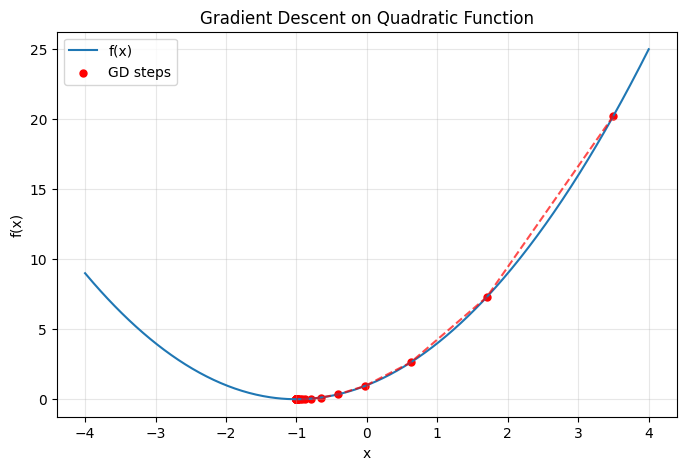

In [11]:
# Test 1: Quadratic function
# f(x) = x^2 + 2x + 1 = (x + 1)^2, cuc tieu tai x = -1
f2 = lambda x: x**2 + 2*x + 1
df2 = lambda x: 2*x + 2

x_star_2, f_star_2, x_hist_2, f_hist_2 = gradient_descent(f2, df2, x0=3.5, lr=0.2, steps=30)
print('Quadratic:')
print(f'  x* ~ {x_star_2:.6f}, f(x*) ~ {f_star_2:.6f}')
plot_optimization(f2, x_hist_2, 'Gradient Descent on Quadratic Function', x_min=-4, x_max=4)

Cubic:
  x* ~ 1.000000, f(x*) ~ -2.000000


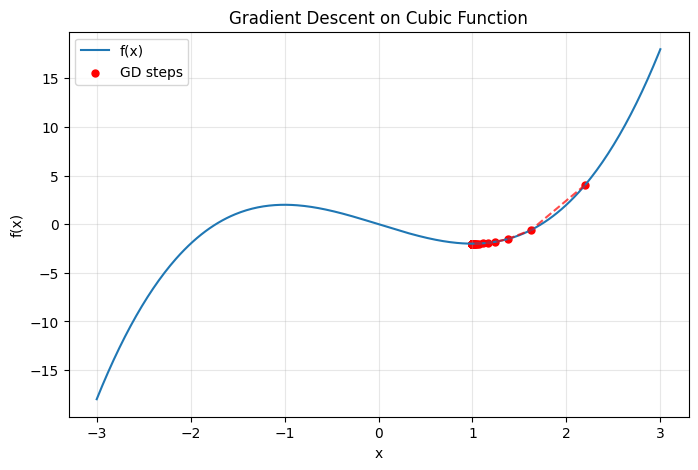

In [12]:
# Test 2: Cubic function
# Chon ham co cuc tri de quan sat hoi tu
# f(x) = x^3 - 3x, f'(x) = 3x^2 - 3
f3 = lambda x: x**3 - 3*x
df3 = lambda x: 3*x**2 - 3

x_star_3, f_star_3, x_hist_3, f_hist_3 = gradient_descent(f3, df3, x0=2.2, lr=0.05, steps=80)
print('Cubic:')
print(f'  x* ~ {x_star_3:.6f}, f(x*) ~ {f_star_3:.6f}')
plot_optimization(f3, x_hist_3, 'Gradient Descent on Cubic Function', x_min=-3, x_max=3)

Quartic:
  x* ~ 1.224745, f(x*) ~ -0.250000


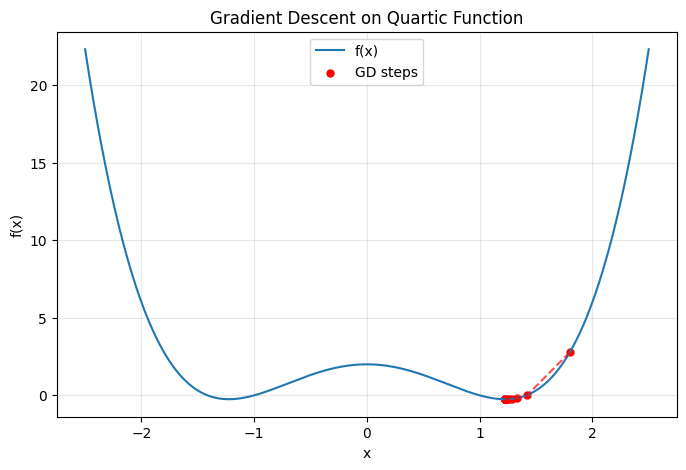

In [13]:
# Test 3: Quartic function
# f(x) = x^4 - 3x^2 + 2, f'(x) = 4x^3 - 6x
f4 = lambda x: x**4 - 3*x**2 + 2
df4 = lambda x: 4*x**3 - 6*x

x_star_4, f_star_4, x_hist_4, f_hist_4 = gradient_descent(f4, df4, x0=1.8, lr=0.03, steps=120)
print('Quartic:')
print(f'  x* ~ {x_star_4:.6f}, f(x*) ~ {f_star_4:.6f}')
plot_optimization(f4, x_hist_4, 'Gradient Descent on Quartic Function', x_min=-2.5, x_max=2.5)

In [14]:
# Regression experiment with synthetic data (true w = 3)
n = 120
X = np.linspace(-2, 2, n)
noise = np.random.normal(0, 0.35, size=n)
y = 3 * X + noise

# Initialize
w = -2.0
lr = 0.05
steps = 200

w_history = [w]
loss_history = []

for _ in range(steps):
    y_pred = w * X
    error = y_pred - y
    loss = np.mean(error**2)
    grad_w = 2 * np.mean(error * X)  # d(MSE)/dw

    w = w - lr * grad_w

    w_history.append(w)
    loss_history.append(loss)

print('Linear Regression with GD:')
print(f'  Final w  = {w:.6f}')
print(f'  True  w  = 3.000000')
print(f'  Final MSE = {loss_history[-1]:.6f}')

Linear Regression with GD:
  Final w  = 3.021483
  True  w  = 3.000000
  Final MSE = 0.104154


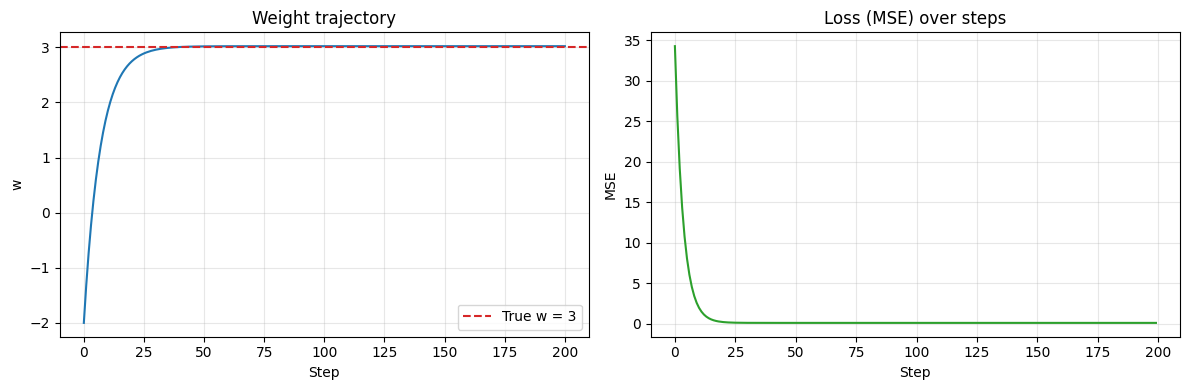

In [15]:
# Visualize weight and loss over updates
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(w_history, color='tab:blue')
axes[0].axhline(3, color='tab:red', linestyle='--', label='True w = 3')
axes[0].set_title('Weight trajectory')
axes[0].set_xlabel('Step')
axes[0].set_ylabel('w')
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].plot(loss_history, color='tab:green')
axes[1].set_title('Loss (MSE) over steps')
axes[1].set_xlabel('Step')
axes[1].set_ylabel('MSE')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

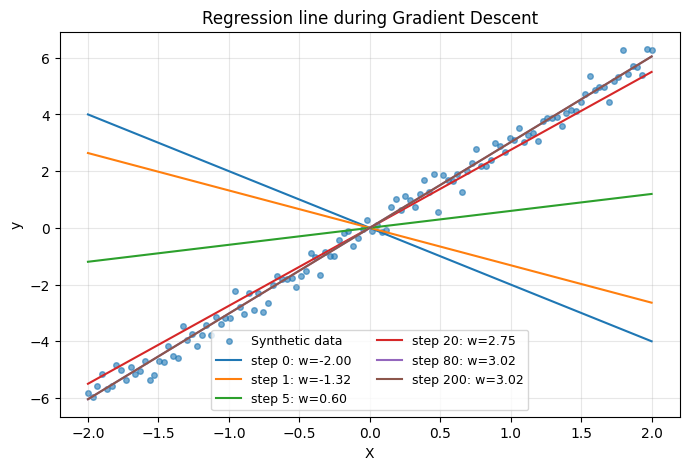

: 

In [ ]:
# Visualize fitted lines at several checkpoints
checkpoints = [0, 1, 5, 20, 80, 200]

plt.figure(figsize=(8, 5))
plt.scatter(X, y, s=16, alpha=0.6, label='Synthetic data')

for c in checkpoints:
    w_c = w_history[c]
    plt.plot(X, w_c * X, linewidth=1.5, label=f'step {c}: w={w_c:.2f}')

plt.title('Regression line during Gradient Descent')
plt.xlabel('X')
plt.ylabel('y')
plt.grid(True, alpha=0.3)
plt.legend(ncol=2, fontsize=9)
plt.show()